# Non-Uniformity Correction table construction
Work done to create the tables for NUC for the CRED2Lite camera and the NIR-multichannels XIMEA camera

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import scienceplots

plt.style.use(['science', 'notebook', 'grid'])

from TherMIFASOL.core.variables.GlobalVariables import (
    LINES_CRED, COLUMNS_CRED, 
    DEPTH_XIQ, WIDTH_XIQ, SUB_LENGTH_XIQ, SUB_WIDTH_XIQ, CHANNEL,
    LAMBDA_NIR, FWHM_NIR, QE_NIR
)
from TherMIFASOL.core.utils.visualization import (
    display_pixels
)
from TherMIFASOL.core.utils.glob import (
    compute_centered_roi
)
from TherMIFASOL.core.data_processing.CRED_functions import (
    load_cred_array, create_table_NUC_CRED, display_nuc_analysis
)
from TherMIFASOL.core.data_processing.XIMEA_functions import (
    split_channel, get_IT_images, temporal_mean, combine_channels,
    create_table_NUC_XIMEA, apply_NUC_XIMEA, select_random_image
)

In [ ]:
PATH_DATA = ""
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[2]
except NameError:
    BASE_DIR = Path().resolve().parents[2]


## CRED2Lite
The analysis was performed using an extended black body at LAMCUBE, configured with an upper temperature setpoint of 550 °C. This reference source is the only one used for conventional NUC (Non-Uniformity Correction) table calibration. However, at the camera’s nominal integration time, the digital values recorded were too low to exploit the full dynamic range. To overcome this limitation, a strategy was employed that involved acquiring images at multiple integration times. This allowed better coverage of the sensor’s dynamic range and enabled the construction of a two-point (or more) NUC table.

We keep the extended black body temperature fixed at 550 °C, which is the maximum reachable setpoint.
The integration time is varied in order to span the full dynamic range of the sensor, while maintaining the black body at a constant temperature.
For this configuration, the following pre-adjusted values were selected. The actual data can be found in the NUC folder.

With Neutral Density Filter:
|  IT [µs]  |    DL [ADU]
-------------|----------------
|    700     |     3,000
|   1500     |     4,500
|   2000     |     6,000
|   2800     |     7,300
|   3500     |     9,000

Without Neutral Density Filter:

| IT [µs]  |   DL  [ADU]
------------|---------------
|    70     |     3 700
|   110     |     4 570
|   200     |     6 200
|   300     |     8 100
|   400     |     9 950


### Load extended black body raw images

In [ ]:
IT_label = ['1', '2', '3', '4', '5']
raw_data_nuc = {}

for it_id in IT_label:
    raw_ext_BB_images = []
    for i in range(200):
        str_data_file_name = os.path.join(
            PATH_DATA, "/calibration/CRED2Lite/NUC/WithNeutralDensityFilter/" + \
                f"NUC_CN550_IT{it_id}/data/im_{i}.npy"
            )
        arr__=load_cred_array(str_data_file_name)
        raw_ext_BB_images.append(arr__)
        
    raw_data_nuc[it_id] = np.asarray(raw_ext_BB_images)


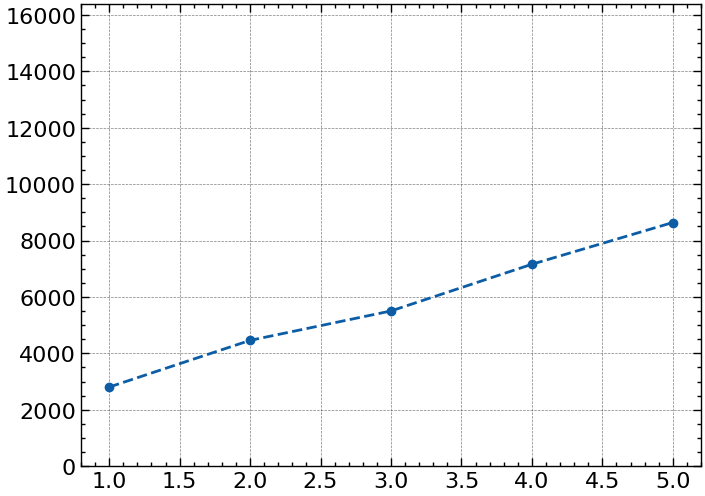

In [22]:
roi_bounds = compute_centered_roi(
    shape=(LINES_CRED, COLUMNS_CRED),
    percent=0.3
)
start_row, end_row, start_col, end_col = roi_bounds

mean_data_over_roi = [np.mean(raw_data_nuc[it_id][start_row:end_row, start_col:end_col]) for it_id in IT_label]
plt.plot(np.arange(1, 6, dtype=int), mean_data_over_roi, 'o--')
plt.ylim(0, 2**14)
plt.show()

### Temporal analysis
Temporal analysis was performed to assess the stability and noise characteristics of randomly selected pixels when exposed to a constant irradiation flux.

In [4]:
bad_pix=[(7, 128), (7, 129), (7, 130)]
good_pix=[(477, 58), (72, 266), (94, 79)]

N = 3
i_j = good_pix
it_id_chosen = '2'
DL_raw = raw_data_nuc[it_id_chosen]
DL_cor = None

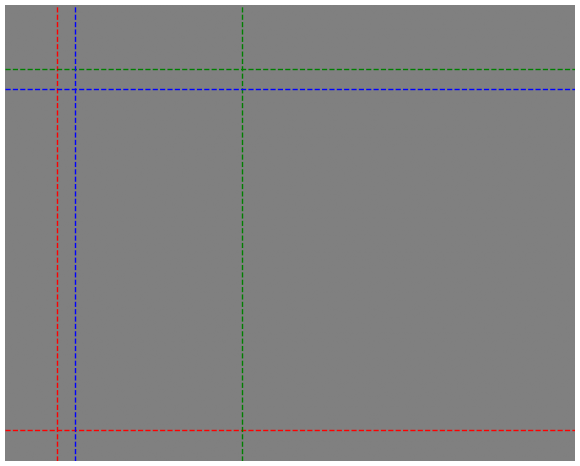

In [5]:
display_pixels(good_pix)

### Temporal noise analysis

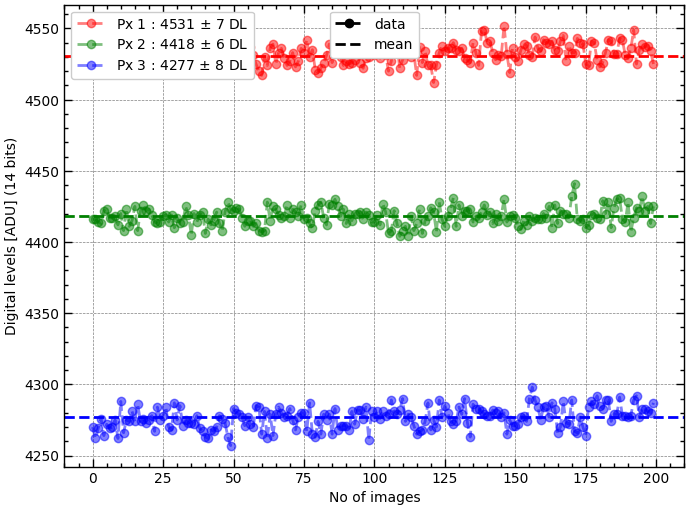

In [6]:
#colors = plt.cm.rainbow(np.linspace(0, 1, N))
colors=['r', 'g', 'b']
shapes=['--', 'o--']
raw=False

if i_j == None:
    i_j=np.vstack((np.random.randint(0,512,N), np.random.randint(0,640,N))).T
    print(i_j)

if raw:
    for cpt,(i,j) in enumerate(i_j):
        col=colors[cpt]
        plt.plot(DL_raw[:,i,j], 'o--', c=col, alpha=0.5, label=f"Pixel {cpt+1} : ({i}-{j})")
    
    plt.xlim(-10,210)
    plt.legend(fontsize=10)

elif not raw and DL_cor==None:
    for cpt,(i,j) in enumerate(i_j):
        col=colors[cpt]
        mea = np.mean(DL_raw[:,i,j])
        DL_raw[145,i,j] = mea
        st = np.std(DL_raw[:,i,j])
        plt.hlines(mea, -10, 210, linestyles='--' ,colors=col, label='')
        # plt.hlines(mea-st, -10, 210, linestyles=':' ,colors=col, label='')
        # plt.hlines(mea+st, -10, 210, linestyles=':' ,colors=col, label='')
        plt.plot(DL_raw[:,i,j], 'o--', c=col, alpha=0.5, label=fr"Px {cpt+1} : {mea:.0f} $\pm$ {st:.0f} DL")

    dat, = plt.plot([-30,-30], [mea, mea], 'o--', color='black')
    moy, = plt.plot([-30,-30], [mea, mea], '--', color='black')
    # ecty, = plt.plot([-30,-30], [mea, mea], ':', color='black')
    
    plt.xlim(-10,210)

    #legend1 = plt.legend([dat, moy, ecty], ["données", "moyennes", "écart-type"], fontsize=10, loc=9)
    legend1 = plt.legend([dat, moy], ["data", "mean"], fontsize=10, loc=9)
    plt.legend(fontsize=10, loc=2)
    plt.gca().add_artist(legend1)

else:
    for cpt,(i,j) in enumerate(i_j):
        col=colors[cpt]
        mea = np.mean(DL_raw[:,i,j])
        new_mean=DL_cor[i,j]
        plt.hlines(mea, -10, 210, linestyles='--' ,colors=col, label='')
        plt.hlines(new_mean, -10, 210, linestyles='-' ,colors=col, label='')
        plt.plot(DL_raw[:,i,j], 'o--', c=col, alpha=0.5, label=f"Pixel {cpt+1} : ({i}-{j})")

    dat, = plt.plot([-30,-30], [mea, mea], 'o--', color='black')
    moy, = plt.plot([-30,-30], [mea, mea], '--', color='black')
    cor, = plt.plot([-30,-30], [mea, mea], '-', color='black')
    
    plt.xlim(-10,210)

    legend1 = plt.legend([dat, moy, cor], ["data", "mean raw", "mean corrected"], fontsize=10, loc=8)
    plt.legend(fontsize=10)
    plt.gca().add_artist(legend1)

plt.tick_params(axis='both', which='major', labelsize=10)
plt.tick_params(axis='both', which='minor', labelsize=10)

plt.xlabel("No of images", fontsize=10)
plt.ylabel("Digital levels [ADU] (14 bits)", fontsize=10)
plt.show()


### Non-uniformity correction
Two points with label '2' and '5'

In [7]:
roi_bounds = compute_centered_roi(
    shape=(LINES_CRED, COLUMNS_CRED),
    percent=0.3
)


select_it_for_nuc = ['2', '5']
raw_images_for_nuc = np.asarray(
    [np.mean(raw_data_nuc[id_it], axis=0) for id_it in select_it_for_nuc]
)

table_NUC = create_table_NUC_CRED(
    array_temporal_mean_images=raw_images_for_nuc,
    roi_bounds=roi_bounds,
    polynomial_degree=len(select_it_for_nuc)-1
)

Fitting polynomial for each pixel...


Pixels: 100%|██████████| 327680/327680 [00:16<00:00, 19327.67it/s]


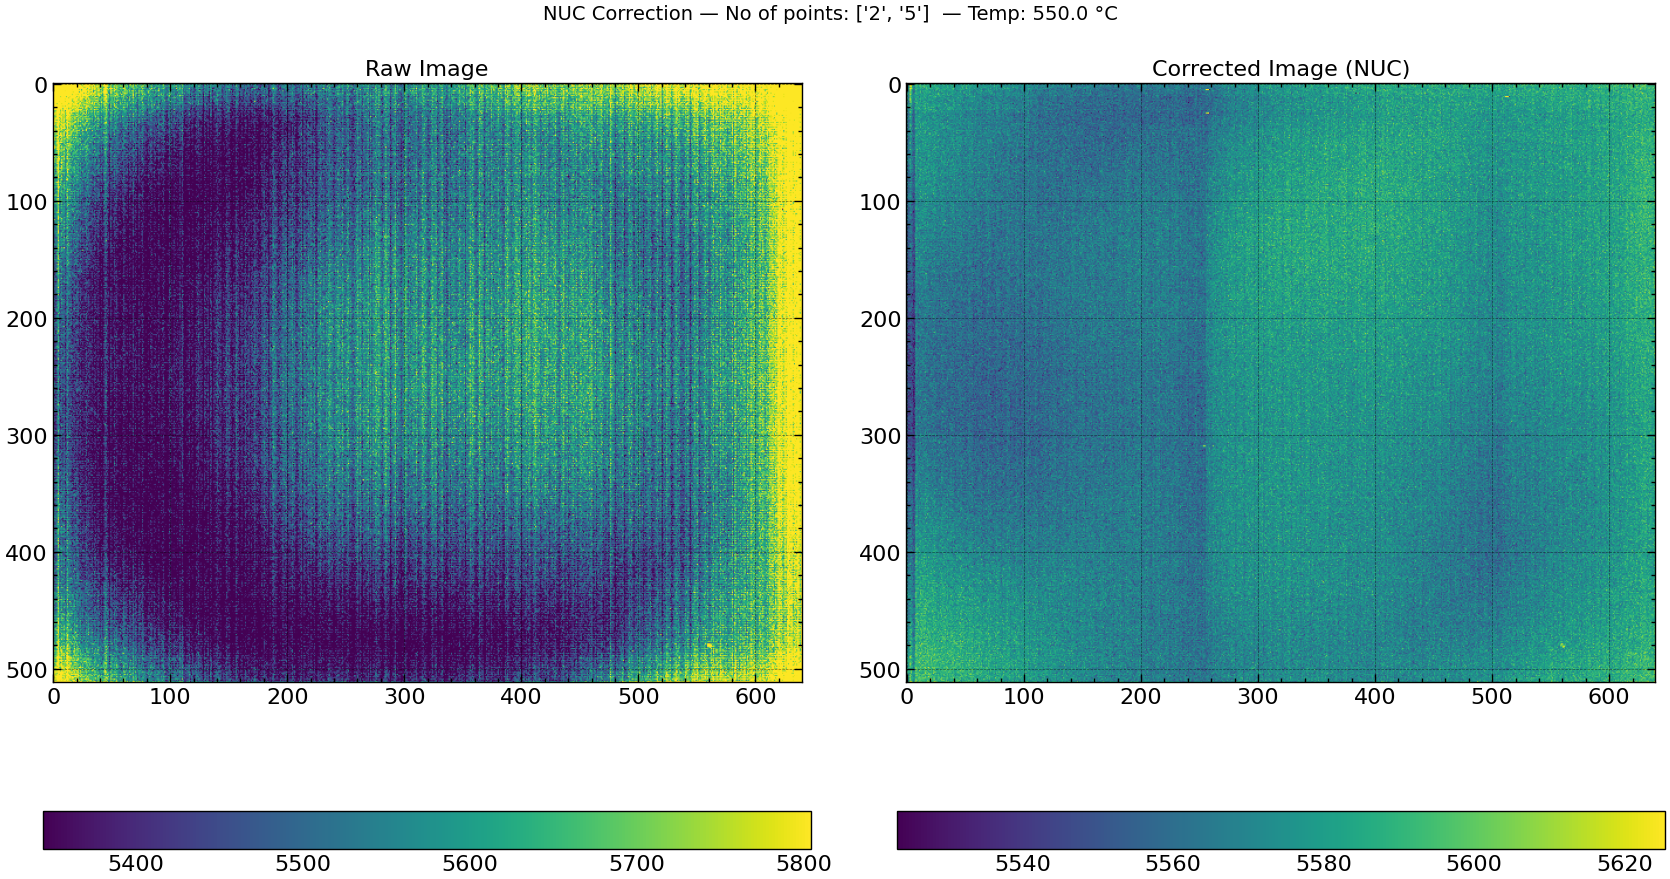

STD raw: 182.37
STD corrected: 12.16


In [8]:
id_it = '3'
id_img=100
display_nuc_analysis(
    raw_image=raw_data_nuc[id_it][id_img],
    nuc_table=table_NUC,
    roi_bounds=roi_bounds,
    No_pts=select_it_for_nuc,
    sensor_temp_c=550
)

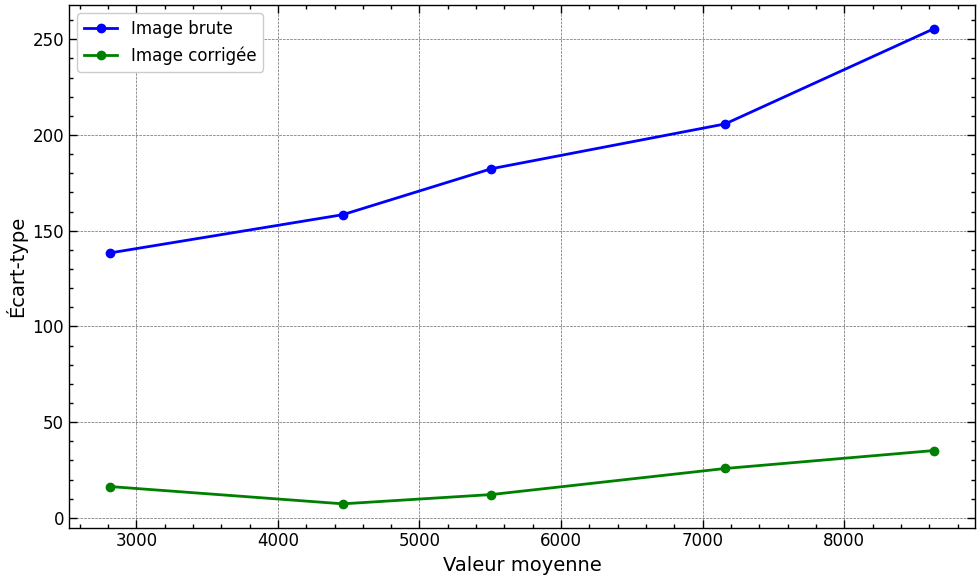

In [9]:
DL_mean = []
std_DL = []
std_DL_cor = []
for IT_ind in IT_label:
    
    DL_brute = raw_data_nuc[IT_ind][id_img]
    DL_brute = DL_brute.astype(np.float64)
    DL_corrected = np.zeros_like(DL_brute)
    deg_NUC = table_NUC.shape[2]

    for i in range(deg_NUC):
        DL_corrected += table_NUC[:,:,i] * DL_brute**(deg_NUC - (i+1))

    DL_mean.append(np.mean(DL_brute))
    std_DL.append(np.std(DL_brute))
    std_DL_cor.append(np.std(DL_corrected))

DL_mean = np.array(DL_mean)
std_DL = np.array(std_DL)
std_DL_cor = np.array(std_DL_cor)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(DL_mean, std_DL, label='Image brute', color='blue', marker='o', linestyle='-', linewidth=2)
ax.plot(DL_mean, std_DL_cor, label='Image corrigée', color='green', marker='o', linestyle='-', linewidth=2)
ax.set_xlabel("Valeur moyenne", fontsize=14)
ax.set_ylabel("Écart-type", fontsize=14)

ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


#### Influence of the degree of polynomial fit on the NUC

Fitting polynomial for each pixel...


Pixels: 100%|██████████| 327680/327680 [00:17<00:00, 19129.26it/s]


2 (512, 640, 3)
Fitting polynomial for each pixel...


Pixels: 100%|██████████| 327680/327680 [00:15<00:00, 21301.36it/s]


3 (512, 640, 4)
Fitting polynomial for each pixel...


Pixels: 100%|██████████| 327680/327680 [00:16<00:00, 20200.37it/s]


4 (512, 640, 5)
Fitting polynomial for each pixel...


Pixels: 100%|██████████| 327680/327680 [00:16<00:00, 19510.90it/s]


5 (512, 640, 6)


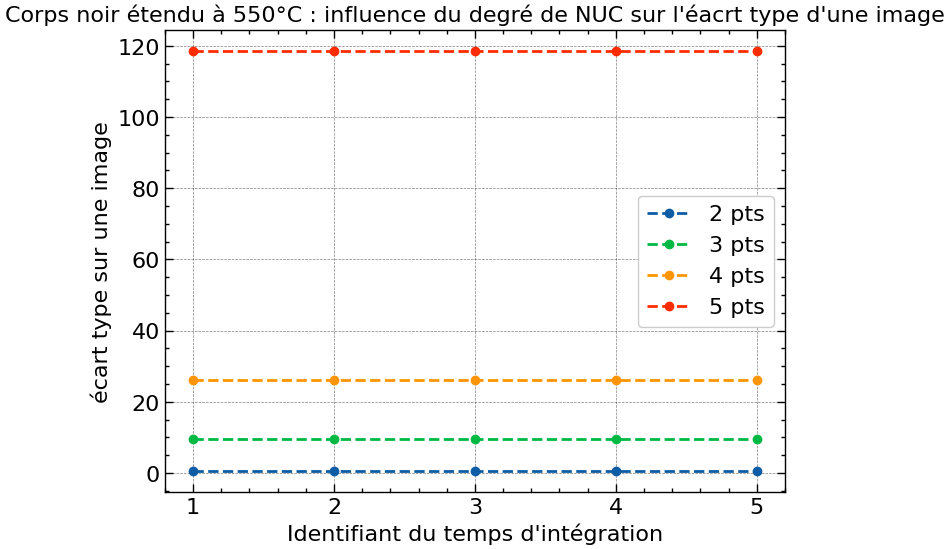

In [10]:
list_deg = [2, 3, 4, 5]
id_img = 16
id_it = '5'

select_it_for_nuc = ['2', '3', '4', '5']
raw_images_for_nuc = np.asarray(
    [np.mean(raw_data_nuc[id_it], axis=0) for id_it in select_it_for_nuc]
)

d = {i:[] for i in list_deg}
for deg_NUC in list_deg:
    table_NUC = create_table_NUC_CRED(
        array_temporal_mean_images=raw_images_for_nuc,
        roi_bounds=roi_bounds,
        polynomial_degree=deg_NUC
    )
    print(deg_NUC, table_NUC.shape)
    for it in IT_label:    
        DL_brute = raw_data_nuc[id_it][id_img]
        DL_brute = DL_brute.astype(np.float64)
        DL_corrected = np.zeros_like(DL_brute)

        for i in range(deg_NUC):
            DL_corrected += table_NUC[:,:,i] * DL_brute**(deg_NUC - (i+1))
        d[deg_NUC].append(np.std(DL_corrected))

for i in list_deg:
    plt.plot(IT_label, d[i], 'o--', label=f'{i} pts')

plt.legend()
plt.title("Corps noir étendu à 550°C : influence du degré de NUC sur l'éacrt type d'une image")
plt.xlabel("Identifiant du temps d'intégration")
plt.ylabel("écart type sur une image")
plt.show()

## Ximea
- Snapshot Mosaic model
- Scans: up to 170 cubes/sec
- 24 Spectral bands
- Spectral range 665-960 nm
- Spatial resolution: approx. 409 x 217 pixels
- Smallest and lightest Hyperspectral camera: 26 x 26 x 31 mm, 32g
- 1.6 Watt and overall SWAP are ideal for Embedded vision systems
- Each camera is spectrally calibrated
- USB3 Vision Compliant - speed 170 datacubes/s
- PCIe interface version - speed 340 datacubes/s

### NUC 1pt on Black Body extended at 550°C

#### Get raw data

In [ ]:
T_CN_NUC=550  # °C
it_label=0
path_NUC_1pts = os.path.join(
    PATH_DATA, f"/calibration/XIMEA/NUC/NUC_CN/XIQ_{T_CN_NUC}_{it_label}"
)

data_NUC={
    'it value':None,
    'TCN':T_CN_NUC,
    'DL mean':None,
    'DL std':None
}

it_value=get_IT_images(path_data_TCN=path_NUC_1pts)
data_NUC['it value']=it_value

array_raw_temporal_mean=temporal_mean(path_data_TCN=path_NUC_1pts)


multi_array_raw_temporal_mean=split_channel(array_raw_temporal_mean)
data_NUC['DL mean']=np.mean(multi_array_raw_temporal_mean, axis=(1,2))
data_NUC['DL std']=np.std(multi_array_raw_temporal_mean, axis=(1,2))


Loading 26 frames from: /home/dolle/Documents/3_These doctorat/6_python/Thermique MIFASOL/data/calibration/XIMEA/NUC/NUC_CN/XIQ_550_0


Loading frames: 100%|██████████| 26/26 [00:00<00:00, 1361.35it/s]


In [12]:
save = True
path_save_results = os.path.join(BASE_DIR, "results/calibration/NUC/XIMEA")

for channel in range(25):
    data = multi_array_raw_temporal_mean[channel]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Image ---
    im = ax1.imshow(data, cmap='viridis')
    mean_val, std_val = np.mean(data), np.std(data)
    im.set_clim(mean_val - 3*std_val, mean_val + 3*std_val)
    plt.colorbar(im, ax=ax1, orientation='horizontal')
    ax1.set_title(f'Channel {channel+1:02d} — Image', fontsize=12)

    # --- Histogramme ---
    ax2.hist(data.ravel(), bins=50, color='steelblue', edgecolor='black', alpha=0.8)
    ax2.set_xlim(0, 256)
    ax2.set_xlabel('Pixel Intensity [8-bit]', fontsize=11)
    ax2.set_ylabel('Frequency', fontsize=11)
    ax2.set_title('Histogram', fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    if save:
        plt.savefig(f"{path_save_results}/Raw_data_forNUC_Ch_{channel+1:02d}_CNetendu.png", dpi=150)
        plt.close(fig)
    else:
        plt.show()

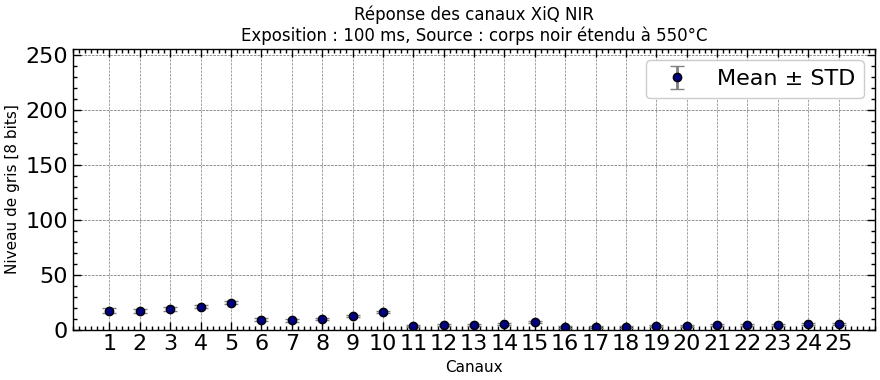

In [13]:
labels = [str(i+1) for i in range(CHANNEL)]
_mean = data_NUC['DL mean']
_std = data_NUC['DL std']

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(labels, _mean, yerr=_std, fmt='o', ecolor='gray', capsize=5,
            markerfacecolor='navy', markeredgecolor='black', markersize=6,
            label='Mean ± STD')

ax.set_title(
    f"Réponse des canaux XiQ NIR\n"
    f"Exposition : {data_NUC['it value']*1e-3:.0f} ms, Source : corps noir étendu à 550°C",
    fontsize=12
)
ax.set_xlabel('Canaux', fontsize=11)
ax.set_ylabel('Niveau de gris [8 bits]', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_ylim(0, 255)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

### NUC 2pts on diffusing photographer's lamp

#### Get data

In [ ]:
# Path to data for NUC 2 pts
T_CN_NUC = 'NUC_LURPA'
path_NUC_2pts = os.path.join(
    PATH_DATA, f"/calibration/XIMEA/NUC/NUC_diffusive_photographer_lamp/"
)


# Define ROI 30% centered
roi_bounds = compute_centered_roi((SUB_WIDTH_XIQ, SUB_LENGTH_XIQ), percent=0.3)
row_start, row_end, col_start, col_end = roi_bounds

# Dictionary data holder
data_NUC = {}

# Loop for the two integration time to use full dynamic scale of the DLs.
for it_label in range(1, 3):  # [1, 2]
    path_data = os.path.join(
        path_NUC_2pts, f"XIQ_{T_CN_NUC}_{it_label}"
    )
    it_value = get_IT_images(path_data_TCN=path_data)
    array2D_raw_temporal_mean = temporal_mean(path_data_TCN=path_data)
    array3D_raw_temporal_mean = split_channel(array2D_raw_temporal_mean)

    mean_full = np.mean(array3D_raw_temporal_mean, axis=(1, 2))
    std_full = np.std(array3D_raw_temporal_mean, axis=(1, 2))

    mean_ROI = np.mean(
        array3D_raw_temporal_mean[:, col_start:col_end, row_start:row_end],
        axis=(1, 2)
    )
    std_ROI = np.std(
        array3D_raw_temporal_mean[:, col_start:col_end, row_start:row_end],
        axis=(1, 2)
    )

    data_NUC[it_label] = {
        'value': it_value,
        'DL mean': mean_full,
        'DL std': std_full,
        'DL mean ROI': mean_ROI,
        'DL std ROI': std_ROI,
        '2D array temporal mean': array2D_raw_temporal_mean
    }


# Intermediate array construction for NUC calculation
MNP_intermediate_mean_1 = np.tile(data_NUC[1]['DL mean ROI'][:, None, None], (1, int(SUB_WIDTH_XIQ), int(SUB_LENGTH_XIQ)))
MNP_intermediate_mean_2 = np.tile(data_NUC[2]['DL mean ROI'][:, None, None], (1, int(SUB_WIDTH_XIQ), int(SUB_LENGTH_XIQ)))

MN_intermediate_mean_1 = combine_channels(MNP_intermediate_mean_1)
MN_intermediate_mean_2 = combine_channels(MNP_intermediate_mean_2)

# Images brutes complètes (non split)
array2D_raw_temporal_mean_1 = data_NUC[1]['2D array temporal mean']
array2D_raw_temporal_mean_2 = data_NUC[2]['2D array temporal mean']

Loading 734 frames from: /home/dolle/Documents/3_These doctorat/6_python/Thermique MIFASOL/data/calibration/XIMEA/NUC/NUC_diffusive_photographer_lamp/XIQ_NUC_LURPA_1


Loading frames: 100%|██████████| 734/734 [00:00<00:00, 828.73it/s]


Loading 680 frames from: /home/dolle/Documents/3_These doctorat/6_python/Thermique MIFASOL/data/calibration/XIMEA/NUC/NUC_diffusive_photographer_lamp/XIQ_NUC_LURPA_2


Loading frames: 100%|██████████| 680/680 [00:00<00:00, 838.79it/s]


In [ ]:
save = True
path_save_results = os.path.join(BASE_DIR, "results/calibration/NUC/XIMEA/Photograph_lamp")
# -----------------------------------------------------

raw_1_split = split_channel(array2D_raw_temporal_mean_1)
raw_2_split = split_channel(array2D_raw_temporal_mean_2)
# -----------------------------------------------------

for channel in range(25):
    data_1 = raw_1_split[channel]
    data_2 = raw_2_split[channel]

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # -------- Line 1 : IT 1 --------
    # Image
    img1 = axes[0, 0].imshow(data_1, cmap='viridis')
    vmin1 = np.mean(data_1) - 3 * np.std(data_1)
    vmax1 = np.mean(data_1) + 3 * np.std(data_1)
    img1.set_clim(vmin1, vmax1)
    plt.colorbar(img1, ax=axes[0, 0], orientation='horizontal')
    axes[0, 0].set_title(f'Canal {channel + 1:02d} - IT1', fontsize=12)

    # Histogram
    axes[0, 1].hist(data_1.ravel(), bins=50, color='royalblue', edgecolor='black')
    axes[0, 1].set_xlim(0, 256)
    axes[0, 1].set_title('Histogram IT1', fontsize=12)
    axes[0, 1].set_xlabel('ADU')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].grid(True, linestyle='--', alpha=0.5)

    # -------- Line 2 : IT 2 --------
    # Image
    img2 = axes[1, 0].imshow(data_2, cmap='viridis')
    vmin2 = np.mean(data_2) - 3 * np.std(data_2)
    vmax2 = np.mean(data_2) + 3 * np.std(data_2)
    img2.set_clim(vmin2, vmax2)
    plt.colorbar(img2, ax=axes[1, 0], orientation='horizontal')
    axes[1, 0].set_title(f'Canal {channel + 1:02d} - IT2', fontsize=12)

    # Histogram
    axes[1, 1].hist(data_2.ravel(), bins=50, color='tomato', edgecolor='black')
    axes[1, 1].set_xlim(0, 256)
    axes[1, 1].set_title('Histogram IT2', fontsize=12)
    axes[1, 1].set_xlabel('ADU')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].grid(True, linestyle='--', alpha=0.5)

    # Affichage ou sauvegarde
    plt.suptitle(f'Canal {channel + 1:02d} — Comparison IT1 / IT2', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save:
        plt.savefig(f"{path_save_results}/Raw_data_forNUC_Ch_{channel+1:02d}.png", dpi=150)
        plt.close(fig)
    else:
        plt.show()

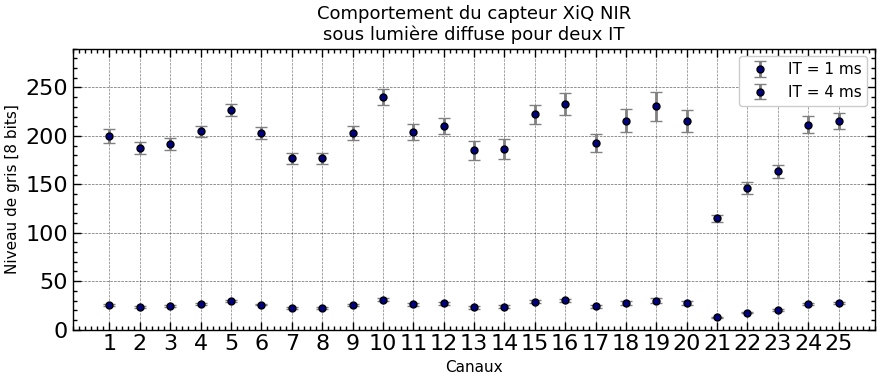

In [32]:
labels = [str(i + 1) for i in range(CHANNEL)]

fig, ax = plt.subplots(figsize=(9, 4))

for it_label in range(1, 3):
    mean_vals = data_NUC[it_label]['DL mean ROI']
    std_vals = data_NUC[it_label]['DL std ROI']
    it_ms = data_NUC[it_label]['value'] * 1e-3  # µs → ms

    ax.errorbar(
        labels, mean_vals, yerr=std_vals, fmt='o',
        label=f"IT = {it_ms:.0f} ms",
        capsize=4, markersize=5,
        markerfacecolor='navy', markeredgecolor='black',
        ecolor='gray'
    )

ax.set_title("Comportement du capteur XiQ NIR\nsous lumière diffuse pour deux IT", fontsize=13)
ax.set_xlabel("Canaux", fontsize=11)
ax.set_ylabel("Niveau de gris [8 bits]", fontsize=11)
ax.set_ylim(0, 290)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

#### Compute NUC table

In [8]:
save_table = False

table_NUC_XIMEA = create_table_NUC_XIMEA(
    raw1=array2D_raw_temporal_mean_1,
    raw2=array2D_raw_temporal_mean_2,
    ref1=MN_intermediate_mean_1,
    ref2=MN_intermediate_mean_2
)

if save_table:
    np.save(f"nuc_{T_CN_NUC}.npy", table_NUC_XIMEA)

#### Check data

##### Try on same optical scene

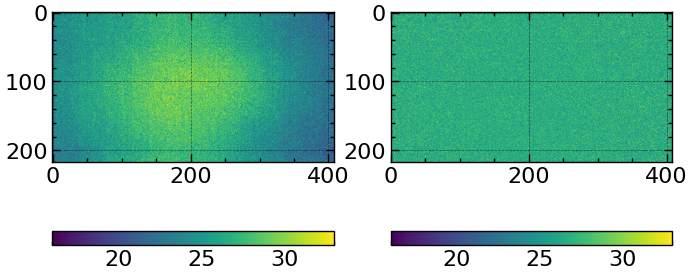

In [9]:
it_label = 1
path_data = os.path.join(
    path_NUC_2pts, f"XIQ_{T_CN_NUC}_{it_label}"
)
# ----------------------------------------------

raw2D_image_to_test = select_random_image(
    path_data_TCN=path_data
)
NUC2D_image_to_test = apply_NUC_XIMEA(
    image=raw2D_image_to_test, 
    table=table_NUC_XIMEA
)
raw3D_image_to_test=split_channel(raw2D_image_to_test)
NUC3D_image_to_test=split_channel(NUC2D_image_to_test)
# ----------------------------------------------


selected_ch=3
min_=raw3D_image_to_test[selected_ch].min()
max_=raw3D_image_to_test[selected_ch].max()

plt.subplot(1, 2, 1)
plt.imshow(raw3D_image_to_test[selected_ch])
plt.clim(min_,max_)
plt.colorbar(orientation='horizontal')
plt.subplot(1, 2, 2)
plt.imshow(NUC3D_image_to_test[selected_ch])
plt.clim(min_,max_)
plt.colorbar(orientation='horizontal')
plt.show()

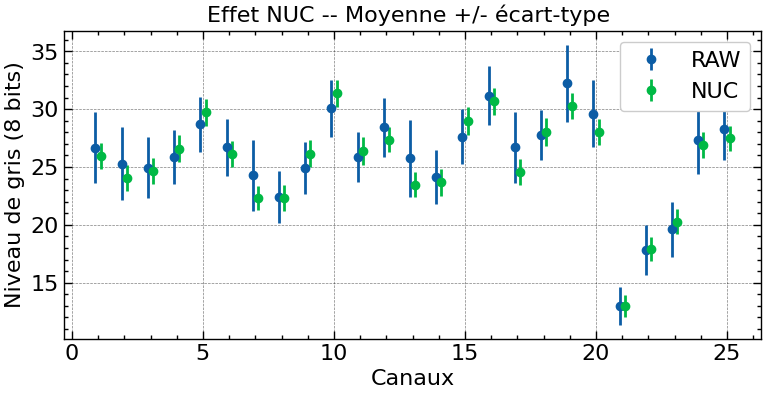

In [10]:
# Analyse NUC SUR IMAGES DE REF
labels=[str(_+1) for _ in range(CHANNEL)]
channels = np.arange(1, 26)

_mean_NUC=np.mean(NUC3D_image_to_test, axis=(1,2))
_mean_RAW=np.mean(raw3D_image_to_test, axis=(1,2))
_std_NUC=np.std(NUC3D_image_to_test, axis=(1,2))
_std_RAW=np.std(raw3D_image_to_test, axis=(1,2))


fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(channels-0.1, _mean_RAW, yerr=_std_RAW, fmt='o', label='RAW')
ax.errorbar(channels+0.1, _mean_NUC, yerr=_std_NUC, fmt='o', label='NUC')
ax.set_title(f"Effet NUC -- Moyenne +/- écart-type ")
ax.yaxis.grid(True)
ax.set_xlabel('Canaux')
ax.set_ylabel('Niveau de gris (8 bits)')
plt.legend()
plt.show()

##### Try on different optical scene

In [ ]:
path_NUC_1pts = os.path.join(
    PATH_DATA, f"/calibration/XIMEA/NUC/NUC_CN/XIQ_550_0"
)

random_BB_extended_image = select_random_image(
    path_data_TCN = path_NUC_1pts
)
NUCed_random_BB_extended_image = apply_NUC_XIMEA(
    image=random_BB_extended_image,
    table=table_NUC_XIMEA
)

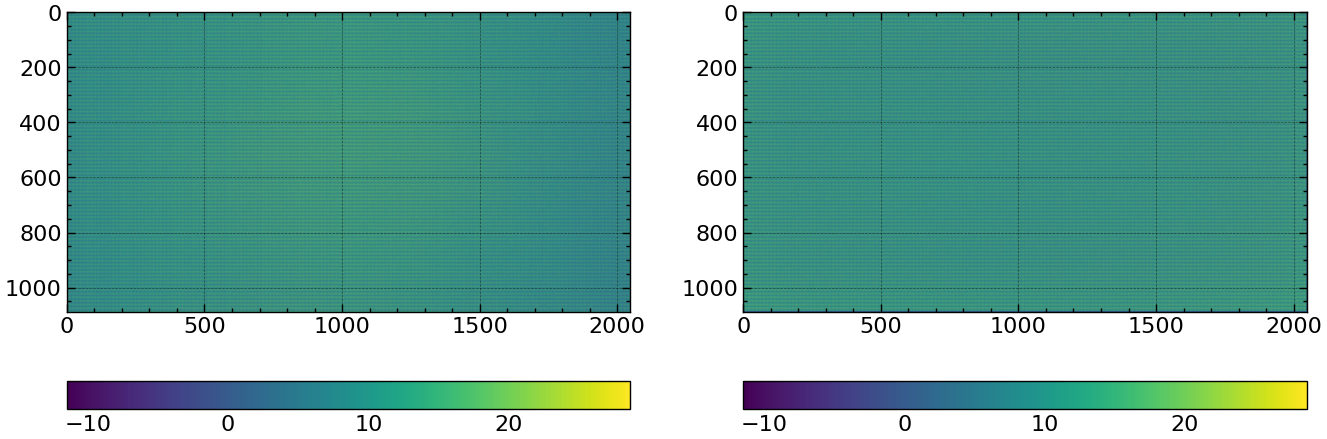

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

img = ax1.imshow(random_BB_extended_image)
clim_vmin = np.mean(random_BB_extended_image) - 3 * np.std(random_BB_extended_image)
clim_vmax = np.mean(random_BB_extended_image) + 3 * np.std(random_BB_extended_image)
img.set_clim(vmin=clim_vmin, vmax=clim_vmax)
fig.colorbar(img, ax=ax1, orientation='horizontal')

img2 = ax2.imshow(NUCed_random_BB_extended_image)
img2.set_clim(vmin=clim_vmin, vmax=clim_vmax)
fig.colorbar(img2, ax=ax2, orientation='horizontal')
plt.show()


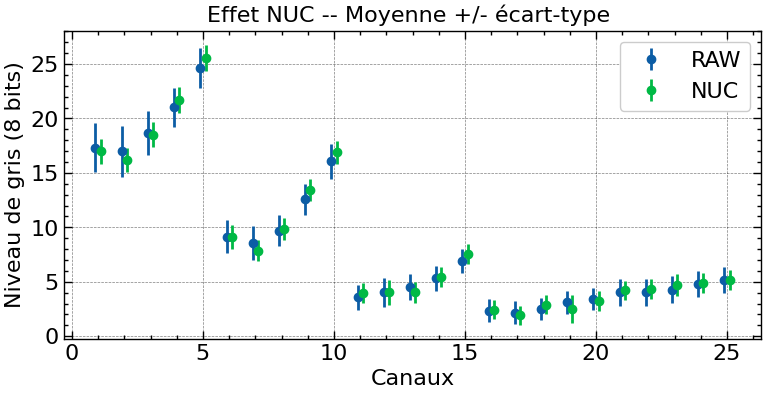

In [15]:
# Analyse NUC
labels=[str(_+1) for _ in range(CHANNEL)]
channels = np.arange(1, 26)

frame_NUC_split = split_channel(NUCed_random_BB_extended_image)
frame_split = split_channel(random_BB_extended_image)

_mean_NUC=np.mean(frame_NUC_split, axis=(1,2))
_mean_RAW=np.mean(frame_split, axis=(1,2))
_std_NUC=np.std(frame_NUC_split, axis=(1,2))
_std_RAW=np.std(frame_split, axis=(1,2))


fig, ax = plt.subplots(figsize=(9, 4))

ax.errorbar(channels-0.1, _mean_RAW, yerr=_std_RAW, fmt='o', label='RAW')
ax.errorbar(channels+0.1, _mean_NUC, yerr=_std_NUC, fmt='o', label='NUC')

ax.set_title(f"Effet NUC -- Moyenne +/- écart-type ")
ax.yaxis.grid(True)
ax.set_xlabel('Canaux')
ax.set_ylabel('Niveau de gris (8 bits)')
plt.legend()
plt.show()
